# **Predicting Customer Subscription to Bank Term Deposits**

## **ML PROJECT**

The objective of this project is to predict whether a bank customer will subscribe to a term deposit using machine learning techniques

Link: https://archive.ics.uci.edu/dataset/222/bank+marketing

A bank runs marketing campaigns where they call up customers and try to convince them to open a "term deposit" — basically a savings account where you lock in your money for a fixed period and earn fixed interest (like an FD in India).
The problem: calling every single customer wastes time and money, because most people say no anyway. So the bank wants to know — before calling — which customers are actually likely to say yes, so they can focus their calls on the right people.

**What I did:**

I took past data from ~45,000 real customer calls (who they called, what they knew about the customer — age, job, account balance, how many times they'd been contacted before, etc. — and whether that customer said yes or no) and built a model that learns the pattern of who tends to say yes.
Once trained, this model can look at a new customer's profile and predict: "this person has a 70% chance of subscribing" or "this person has a 2% chance" — so the bank can call the high-probability people first instead of calling randomly.

**The key finding, in one line:**

The single biggest clue that a customer will say yes again is if they said yes to a similar offer before. Customers with no contact history are much harder to predict and much less likely to convert.

**Why it matters (the business pitch):**

Instead of cold-calling every customer equally, the bank can now rank customers by predicted likelihood and prioritize the calls that are actually worth making — saving time, saving money, and getting a better yes-rate per call made.

### **DATA LOADING**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [2]:
df=pd.read_csv('bank_dataset.csv')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### **CLEANING**

In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [8]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [9]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [10]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

******************************************************************************************************************************************************

no null values

no duplicates

unknown values in job, education, contact, poutcome -> valid values

pdays = -1 -> "never contacted before"
balance = -ve -> overdraft

******************************************************************************************************************************************************

### **BOXPLOT(outliers)**

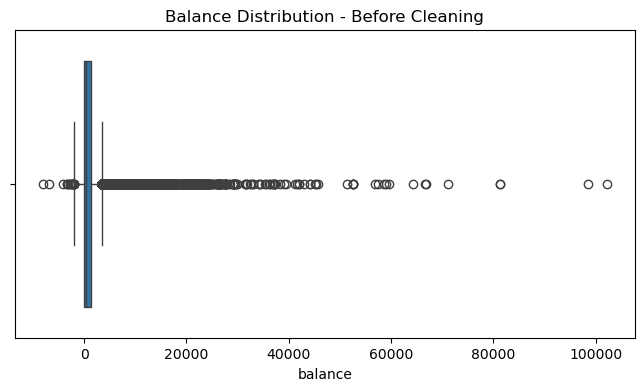

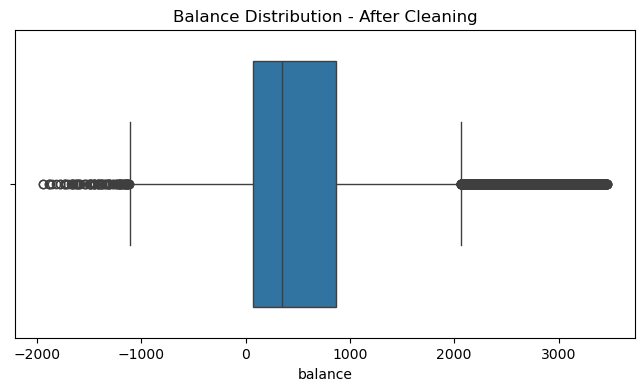

Min    : -1944
Q1     : 73.0
Median : 349.0
Q3     : 869.0
Max    : 3462
IQR    : 796.0


In [12]:
# ================= BALANCE =================
plt.figure(figsize=(8,4))
sns.boxplot(x=df['balance'])
plt.title('Balance Distribution - Before Cleaning')
plt.show()

Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_balance = df[(df['balance'] >= lower) & (df['balance'] <= upper)]['balance'].median()
df['balance'] = df['balance'].apply(lambda x: median_balance if x < lower or x > upper else x)
df['balance'] = df['balance'].astype(int)

plt.figure(figsize=(8,4))
sns.boxplot(x=df['balance'])
plt.title('Balance Distribution - After Cleaning')
plt.show()

Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
print("Min    :", df['balance'].min())
print("Q1     :", Q1)
print("Median :", df['balance'].median())
print("Q3     :", Q3)
print("Max    :", df['balance'].max())
print("IQR    :", Q3 - Q1)

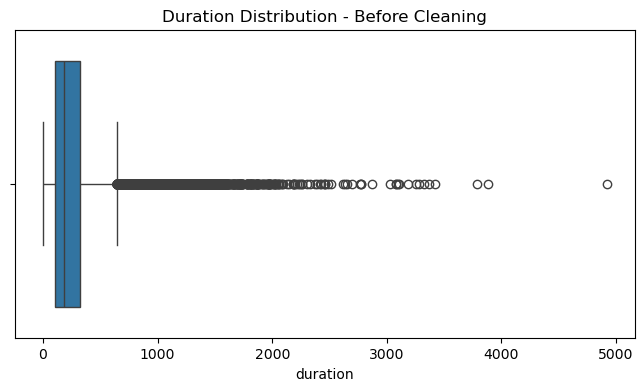

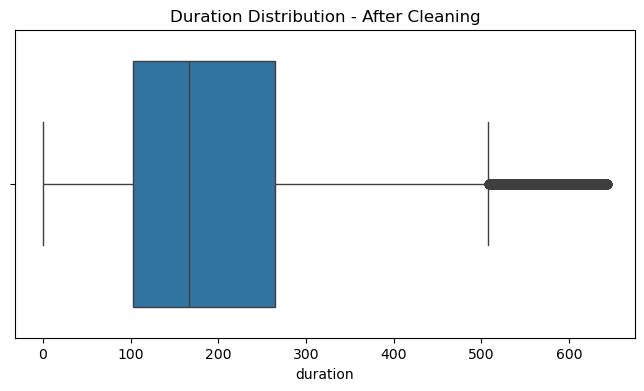

Min    : 0
Q1     : 103.0
Median : 167.0
Q3     : 265.0
Max    : 643
IQR    : 162.0


In [13]:
# ================= DURATION =================
plt.figure(figsize=(8,4))
sns.boxplot(x=df['duration'])
plt.title('Duration Distribution - Before Cleaning')
plt.show()

Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_duration = df[(df['duration'] >= lower) & (df['duration'] <= upper)]['duration'].median()
df['duration'] = df['duration'].apply(lambda x: median_duration if x < lower or x > upper else x)
df['duration'] = df['duration'].astype(int)

plt.figure(figsize=(8,4))
sns.boxplot(x=df['duration'])
plt.title('Duration Distribution - After Cleaning')
plt.show()

Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
print("Min    :", df['duration'].min())
print("Q1     :", Q1)
print("Median :", df['duration'].median())
print("Q3     :", Q3)
print("Max    :", df['duration'].max())
print("IQR    :", Q3 - Q1)

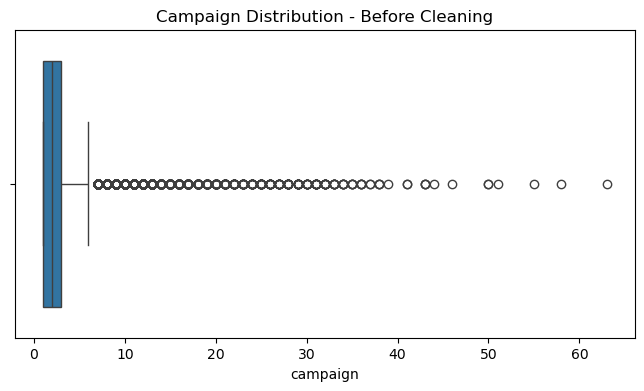

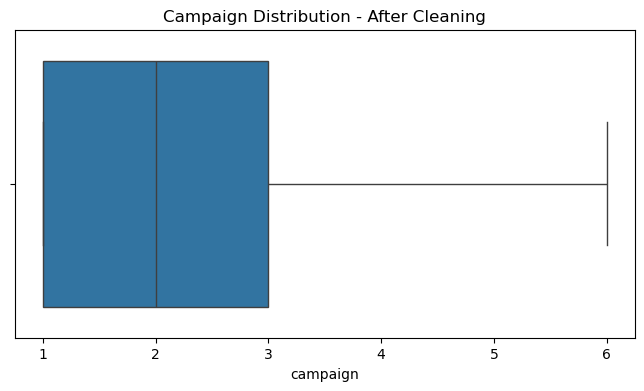

Min    : 1
Q1     : 1.0
Median : 2.0
Q3     : 3.0
Max    : 6
IQR    : 2.0


In [14]:
# ================= CAMPAIGN =================
plt.figure(figsize=(8,4))
sns.boxplot(x=df['campaign'])
plt.title('Campaign Distribution - Before Cleaning')
plt.show()

Q1 = df['campaign'].quantile(0.25)
Q3 = df['campaign'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_campaign = df[(df['campaign'] >= lower) & (df['campaign'] <= upper)]['campaign'].median()
df['campaign'] = df['campaign'].apply(lambda x: median_campaign if x < lower or x > upper else x)
df['campaign'] = df['campaign'].astype(int)

plt.figure(figsize=(8,4))
sns.boxplot(x=df['campaign'])
plt.title('Campaign Distribution - After Cleaning')
plt.show()

Q1 = df['campaign'].quantile(0.25)
Q3 = df['campaign'].quantile(0.75)
print("Min    :", df['campaign'].min())
print("Q1     :", Q1)
print("Median :", df['campaign'].median())
print("Q3     :", Q3)
print("Max    :", df['campaign'].max())
print("IQR    :", Q3 - Q1)

******************************************************************************************************************************************************

We calculated Q1 (25th percentile) and Q3 (75th percentile) — the range where the middle 50% of data sits
Anything beyond 1.5× that range (above Q3 or below Q1) was flagged as an outlier

**What we did about them**

We did not delete any rows — every customer stayed in the dataset
Instead, we replaced outlier values with the median (the middle value), so extreme numbers wouldn't distort the model, but no data was lost

**Which columns we treated, and why**

Balance, Duration, Campaign — these had a meaningful number of extreme values, so we cleaned them
Age — very few extreme values, so left as-is
Pdays, Previous — the "outliers" here are actually meaningful (e.g., -1 means "never contacted before"), so we deliberately left them untouched to avoid losing real information

******************************************************************************************************************************************************

### **COMPARISON (used later on)**

In [15]:
df0 = df.copy()

df1 = df.drop(columns=['duration'])

print("With duration shape:", df0.shape)
print("Without duration shape:", df1.shape)

With duration shape: (45211, 17)
Without duration shape: (45211, 16)


******************************************************************************************************************************************************

right now we are using df_main as the default dataset in which we have dropped the duration column.
we have also made a copy of dataset which includes duration col that can be used later for comparison.

******************************************************************************************************************************************************

### **ENCODING**

In [16]:
df2 = df1.copy()

binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    df2[col] = df2[col].map({'no': 0, 'yes': 1})

In [17]:
nominal_cols = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']

df2 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df2.shape)

Shape after encoding: (45211, 42)


******************************************************************************************************************************************************

Binary columns (default, housing, loan, y) only have two values — "yes"/"no" — so we just convert them straight to 1/0, since a model can't understand text.

Multi-category columns (job, education, etc.) have more than two categories, so we use one-hot encoding — this creates a separate 0/1 column for each category (e.g., job_student, job_retired) instead of assigning random numbers, which would wrongly imply some categories are "bigger" than others.

drop_first=True drops one category per column to avoid redundancy (if you know all the other job columns are 0, you already know it must be the dropped one) — this avoids a technical issue called the "dummy variable trap."

******************************************************************************************************************************************************

In [18]:
df2['y'].value_counts(normalize=True)*100

y
0    88.30152
1    11.69848
Name: proportion, dtype: float64

### **FEATURE ENGINEERING**

In [19]:
df2['was_contacted_before'] = df1['pdays'].apply(lambda x: 0 if x == -1 else 1)
print(df2['was_contacted_before'].value_counts())

was_contacted_before
0    36954
1     8257
Name: count, dtype: int64


******************************************************************************************************************************************************

pdays = -1 -> never contacted before -> 0

pdays ≠ 1 -> contacted before -> 1

******************************************************************************************************************************************************

In [20]:
def age_bucket(age):
    if age < 30:
        return 'young'
    elif age < 60:
        return 'middle'
    else:
        return 'senior'

df2['age_group'] = df1['age'].apply(age_bucket)

df2 = pd.get_dummies(df2, columns=['age_group'], drop_first=True)
print(df2.filter(like='age_group').sum())

age_group_senior    1784
age_group_young     5273
dtype: int64


In [21]:
df2['contact_intensity'] = df1['campaign'] + df1['previous']
print(df2['contact_intensity'].describe())

count    45211.000000
mean         2.701466
std          2.626721
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        277.000000
Name: contact_intensity, dtype: float64


******************************************************************************************************************************************************

Combines current campaign contacts + previous campaign contacts into one measure

******************************************************************************************************************************************************

In [22]:
Q1 = df2['contact_intensity'].quantile(0.25)
Q3 = df2['contact_intensity'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_ci = df2[(df2['contact_intensity'] >= lower) & (df2['contact_intensity'] <= upper)]['contact_intensity'].median()
df2['contact_intensity'] = df2['contact_intensity'].apply(lambda x: median_ci if x < lower or x > upper else x)

print(df2['contact_intensity'].describe())

count    45211.000000
mean         2.372719
std          1.361949
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: contact_intensity, dtype: float64


### **STATISTICAL TESTS**

In [23]:
categorical_cols = ['job', 'marital', 'education', 'contact', 'poutcome', 'month', 'default', 'housing', 'loan']

print("CHI-SQUARE TEST RESULTS")
print("-" * 50)
for col in categorical_cols:
    contingency_table = pd.crosstab(df1[col], df1['y'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    significance = "Significant" if p < 0.05 else "Not significant"
    print(f"{col:12s} | chi2 = {chi2:10.2f} | p-value = {p:.5f} | {significance}")

CHI-SQUARE TEST RESULTS
--------------------------------------------------
job          | chi2 =     836.11 | p-value = 0.00000 | Significant
marital      | chi2 =     196.50 | p-value = 0.00000 | Significant
education    | chi2 =     238.92 | p-value = 0.00000 | Significant
contact      | chi2 =    1035.71 | p-value = 0.00000 | Significant
poutcome     | chi2 =    4391.51 | p-value = 0.00000 | Significant
month        | chi2 =    3061.84 | p-value = 0.00000 | Significant
default      | chi2 =      22.20 | p-value = 0.00000 | Significant
housing      | chi2 =     874.82 | p-value = 0.00000 | Significant
loan         | chi2 =     209.62 | p-value = 0.00000 | Significant


In [24]:
numeric_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']

print("\nT-TEST RESULTS")
print("-" * 50)
for col in numeric_cols:
    group_yes = df1[df1['y'] == 'yes'][col]
    group_no = df1[df1['y'] == 'no'][col]
    t_stat, p_val = ttest_ind(group_yes, group_no, equal_var=False)
    significance = "Significant" if p_val < 0.05 else "Not significant"
    print(f"{col:12s} | t-stat = {t_stat:8.2f} | p-value = {p_val:.5f} | {significance}")


T-TEST RESULTS
--------------------------------------------------
age          | t-stat =     4.32 | p-value = 0.00002 | Significant
balance      | t-stat =    15.62 | p-value = 0.00000 | Significant
campaign     | t-stat =   -14.50 | p-value = 0.00000 | Significant
pdays        | t-stat =    18.94 | p-value = 0.00000 | Significant
previous     | t-stat =    18.12 | p-value = 0.00000 | Significant


### **TEST-TRAIN SPLIT**

In [25]:
X = df2.drop(columns=['y'])
y = df2['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (36168, 45)
X_test shape: (9043, 45)
y_train distribution:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64
y_test distribution:
 y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [26]:
numeric_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contact_intensity']
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train[numeric_cols].describe()

,age,balance,day,campaign,pdays,previous,contact_intensity
count,3.616800e+04,3.616800e+04,3.616800e+04,3.616800e+04,3.616800e+04,3.616800e+04,3.616800e+04
mean,-1.194454e-16,5.048924e-17,8.801237e-17,2.937020e-17,2.514639e-17,-1.493067e-17,9.292378e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-2.154244e+00,-3.177270e+00,-1.778469e+00,-8.825858e-01,-4.109099e-01,-2.415087e-01,-1.007091e+00
25%,-7.427358e-01,-6.692882e-01,-9.383206e-01,-8.825858e-01,-4.109099e-01,-2.415087e-01,-1.007091e+00
50%,-1.781323e-01,-3.275167e-01,2.184858e-02,-9.426773e-02,-4.109099e-01,-2.415087e-01,-2.713769e-01
75%,6.687728e-01,3.261991e-01,6.219543e-01,6.940503e-01,-4.109099e-01,-2.415087e-01,4.643370e-01
max,5.091500e+00,3.541337e+00,1.822166e+00,3.059004e+00,8.295054e+00,1.139264e+02,2.671479e+00


### **COMPARE MODELS**

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [28]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Naive Bayes,0.849939,0.379338,0.444234,0.409229
0,Logistic Regression,0.770651,0.284928,0.636106,0.393567
2,Random Forest,0.892182,0.623145,0.198488,0.301075
1,Decision Tree,0.841093,0.309930,0.292060,0.300730
3,KNN,0.882451,0.493261,0.172968,0.256123


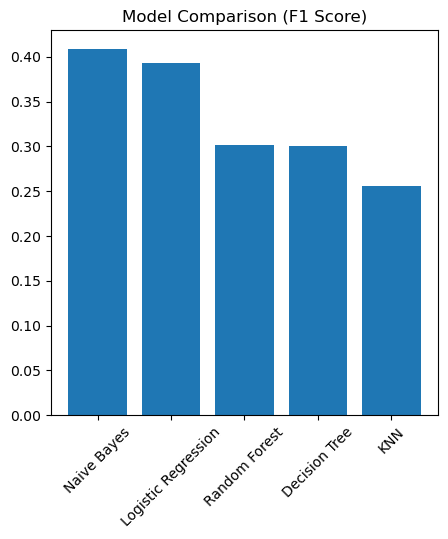

In [30]:
plt.figure(figsize=(5,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=45)
plt.show()

In [31]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model based on F1 Score:", best_model_name)

Best Model based on F1 Score: Naive Bayes


In [32]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [33]:
y_pred = best_model.predict(X_test)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8499391794758376

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      7985
           1       0.38      0.44      0.41      1058

    accuracy                           0.85      9043
   macro avg       0.65      0.67      0.66      9043
weighted avg       0.86      0.85      0.85      9043


Confusion Matrix:

[[7216  769]
 [ 588  470]]


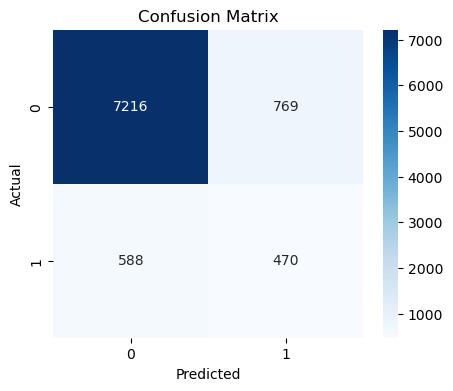

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

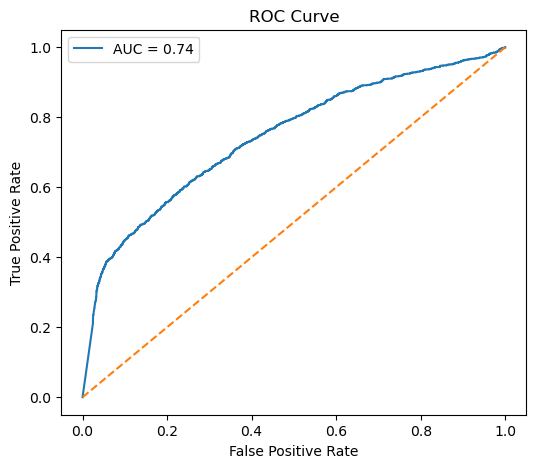

In [38]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### **TESTING ON SAMPLE DATA**

In [37]:
def make_customer(overrides):
    base = {col: 0 for col in X_train.columns}
    base.update(overrides)
    return pd.DataFrame([base])[X_train.columns]

numeric_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contact_intensity']

#Customer 1
customer_avg = make_customer({
    'age': 35, 'balance': 1500, 'day': 15, 'campaign': 2, 'pdays': -1, 'previous': 0,
    'contact_intensity': 2, 'was_contacted_before': 0,
    'housing': 1, 'job_management': 1, 'marital_married': 1,
    'education_tertiary': 1, 'poutcome_unknown': 1, 'month_may': 1})

#Customer 2
customer_strong = make_customer({
    'age': 35, 'balance': 1500, 'day': 15, 'campaign': 2, 'pdays': 90, 'previous': 3,
    'contact_intensity': 5, 'was_contacted_before': 1,
    'housing': 0, 'job_management': 1, 'marital_married': 1,
    'education_tertiary': 1, 'poutcome_success': 1, 'month_mar': 1})

for name, cust in [('Average Customer', customer_avg), ('Strong Signal Customer', customer_strong)]:
    cust_scaled = cust.copy()
    cust_scaled[numeric_cols] = scaler.transform(cust_scaled[numeric_cols])
    pred = best_model.predict(cust_scaled)[0]
    prob = best_model.predict_proba(cust_scaled)[:, 1][0]
    print(f"{name}: Prediction = {'Yes' if pred==1 else 'No'} | Probability of subscribing = {prob*100:.2f}%")

Average Customer: Prediction = No | Probability of subscribing = 0.01%
Strong Signal Customer: Prediction = Yes | Probability of subscribing = 100.00%


******************************************************************************************************************************************************

A customer's response to a previous campaign is the single strongest predictor — those who said yes before are far more likely to say yes again, confirming the value of tracking and prioritizing repeat engagement in future campaigns.

******************************************************************************************************************************************************

### **CONCLUSION**

This project compared five ML models — Logistic Regression, Decision Tree, Random Forest, KNN, and Naive Bayes — to predict term deposit subscription on the UCI Bank Marketing dataset. After balancing class weights across models, Naive Bayes gave the best F1 score (0.409), correctly identifying subscribers better than the alternatives despite lower overall accuracy.

### **KEY INSIGHTS**

1. Past campaign outcome (poutcome_success) is the single strongest predictor of subscribing again
2. Contact intensity and prior contact history meaningfully raise subscription likelihood
3. All tested demographic and financial variables were statistically significant, but with weaker individual effect than campaign history

### **BUSINESS RECOMMENDATION**
1. Prioritize customers with a prior successful campaign response for outreach
2. Reduce repeated contact with customers who show no engagement signal
3. Use model-ranked probability scores to sequence calling lists instead of contacting randomly
